# GPU Memory Growth and Importing libraries


In [ ]:
#importing libraries
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')

if gpus:
    try:
        for gpu in gpus:
            if not tf.config.experimental.get_memory_growth(gpu):
                tf.config.experimental.set_memory_growth(gpu, True)
        print("Memory growth enabled")
    except RuntimeError as e:
        print(e)

print("GPUs:", gpus)

# Then do everything else

import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.utils import image_dataset_from_directory
import pandas as pd

Memory growth enabled
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [10]:

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.10.0


## data preprocessing

### Before Undersampling

In [11]:
training_set=image_dataset_from_directory(
    "C:/Users/HP/Downloads/ML/eye_disease/train",
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=16,
    image_size=(160, 160),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    
)

validation_set=image_dataset_from_directory(
    "C:/Users/HP/Downloads/ML/eye_disease/val",
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=16,
    image_size=(160, 160),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    
)


Found 34324 files belonging to 4 classes.
Found 21861 files belonging to 4 classes.


In [12]:
training_set

<BatchDataset element_spec=(TensorSpec(shape=(None, 160, 160, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 4), dtype=tf.float32, name=None))>

In [13]:
validation_set

<BatchDataset element_spec=(TensorSpec(shape=(None, 160, 160, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 4), dtype=tf.float32, name=None))>

## Dataset Overview (Basic EDA)
### We are Checking
1.Number of classes

2.Total images per class

3.Image shape & datatype

In [15]:
import os
import pandas as pd


data_dir =     "C:/Users/HP/Downloads/ML/eye_disease/val"

classes = os.listdir(data_dir)

data =[]
for cls in classes:
    path= os.path.join(data_dir,cls)
    count = len(os.listdir(path))
    data.append([cls,count])

print("validation dataset \n")
df = pd.DataFrame(data, columns=["Class","No_of_Images"])
print(df,"\n\n\n")





data_dir = "C:/Users/HP/Downloads/ML/eye_disease/train_original"
classes = os.listdir(data_dir)

data =[]
for cls in classes:
    path= os.path.join(data_dir,cls)
    count = len(os.listdir(path))
    data.append([cls,count])

print("training dataset \n")
df = pd.DataFrame(data, columns=["Class","No_of_Images"])
print(df)



validation dataset 

    Class  No_of_Images
0     CNV          7491
1     DME          2319
2  DRUSEN          1773
3  NORMAL         10278 



training dataset 

    Class  No_of_Images
0     CNV         26218
1     DME          8118
2  DRUSEN          6206
3  NORMAL         35973


## Class Distribution Visualization

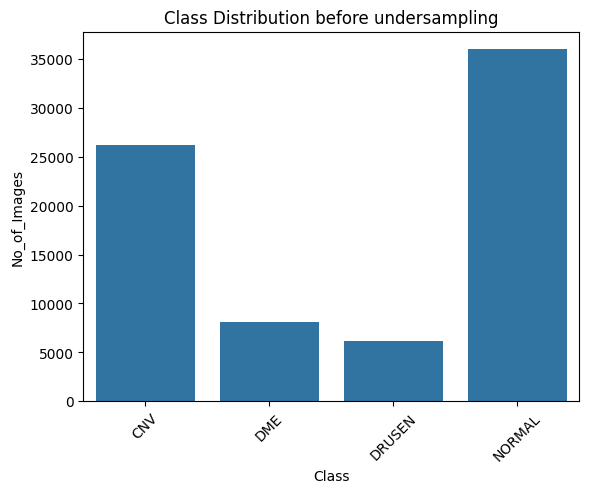

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.barplot(x=df["Class"],y= df["No_of_Images"])
plt.title("Class Distribution before undersampling")
plt.xticks(rotation= 45)
plt.show()

# Undersampling of Data and EDA after undersampling



In [17]:
class_names = training_set.class_names
print(class_names)


['CNV', 'DME', 'DRUSEN', 'NORMAL']


In [18]:
minority_classes = [1, 2]   # DME, DRUSEN


### Undersampling using Kmeans (Time consuming)

#### selects the most distinct images only

In [19]:
# import numpy as np
# import tensorflow as tf
# from pathlib import Path
# from concurrent.futures import ThreadPoolExecutor, as_completed
# from sklearn.cluster import MiniBatchKMeans
# import os

# # ── configuration ─────────────────────────────────────────────────────────────
# TARGET_PER_CLASS = 10_000        # images to keep per class
# EMBED_SIZE       = (32, 32)      # 32×32 = 3,072 dims vs 12,288 at 64×64 — 4× faster KMeans
# SUPPORTED_EXTS   = {".jpg", ".jpeg", ".png", ".bmp", ".tiff"}
# TRAIN_DIR        = "./train"
# NUM_WORKERS      = os.cpu_count()   # parallel threads for image loading

# # DME (8,118) and DRUSEN (6,206) are below target — auto-skipped.
# CLASSES_TO_CHECK = ["CNV", "DME", "DRUSEN", "NORMAL"]


# # ── helpers ───────────────────────────────────────────────────────────────────
# def load_flat(path: Path) -> np.ndarray:
#     """Load one image → flat float32 vector normalised to [0, 1]."""
#     try:
#         raw = tf.io.read_file(str(path))
#         img = tf.image.decode_image(raw, channels=3, expand_animations=False)
#         img = tf.image.resize(img, EMBED_SIZE)
#         return (img.numpy() / 255.0).reshape(-1).astype(np.float32)
#     except Exception:
#         return np.zeros(EMBED_SIZE[0] * EMBED_SIZE[1] * 3, dtype=np.float32)


# def embed_all_parallel(paths: list) -> np.ndarray:
#     """
#     Load and embed all images in parallel using ThreadPoolExecutor.
#     Order is preserved by submitting with index and sorting results.
#     """
#     results = {}
#     with ThreadPoolExecutor(max_workers=NUM_WORKERS) as pool:
#         futures = {pool.submit(load_flat, p): i for i, p in enumerate(paths)}
#         done = 0
#         for future in as_completed(futures):
#             idx = futures[future]
#             results[idx] = future.result()
#             done += 1
#             if done % 2000 == 0:
#                 print(f"    Embedded {done}/{len(paths)} ...")
#     # Reconstruct in original order
#     return np.stack([results[i] for i in range(len(paths))])


# def kmeans_keep_indices(X: np.ndarray, n_keep: int) -> set:
#     """
#     MiniBatchKMeans on X with n_keep clusters.
#     Returns a set of row indices — one per cluster, closest sample to its centre.
#     """
#     print(f"    MiniBatchKMeans k={n_keep} on {X.shape[0]} samples "
#           f"(dims={X.shape[1]}) ...")
#     km = MiniBatchKMeans(
#         n_clusters=n_keep,
#         batch_size=4096,
#         n_init=3,
#         random_state=42,
#         verbose=0,
#     )
#     km.fit(X)

#     keep = set()
#     for c in range(n_keep):
#         members = np.where(km.labels_ == c)[0]
#         if len(members) == 0:
#             continue
#         dists = np.linalg.norm(X[members] - km.cluster_centers_[c], axis=1)
#         keep.add(int(members[np.argmin(dists)]))
#     return keep


# # ── main loop ─────────────────────────────────────────────────────────────────
# for class_name in CLASSES_TO_CHECK:
#     class_dir = Path(TRAIN_DIR) / class_name

#     if not class_dir.is_dir():
#         print(f"[{class_name}] Not found — skipping.")
#         continue

#     all_images = sorted(
#         p for p in class_dir.iterdir()
#         if p.suffix.lower() in SUPPORTED_EXTS
#     )
#     n_total = len(all_images)

#     if n_total <= TARGET_PER_CLASS:
#         print(f"[{class_name}] {n_total} images ≤ {TARGET_PER_CLASS} target — skipping.")
#         continue

#     print(f"\n[{class_name}] {n_total} images → keeping {TARGET_PER_CLASS} "
#           f"(deleting {n_total - TARGET_PER_CLASS})")

#     print(f"  [1/3] Embedding all images in parallel at {EMBED_SIZE} "
#           f"using {NUM_WORKERS} workers ...")
#     X = embed_all_parallel(all_images)

#     print(f"  [2/3] Selecting most diverse {TARGET_PER_CLASS} via KMeans ...")
#     keep_set = kmeans_keep_indices(X, TARGET_PER_CLASS)

#     print(f"  [3/3] Deleting {n_total - len(keep_set)} images from {class_dir} ...")
#     n_deleted = 0
#     for i, img_path in enumerate(all_images):
#         if i not in keep_set:
#             img_path.unlink()   # permanent delete — original folder is your backup
#             n_deleted += 1

#     remaining = len([p for p in class_dir.iterdir() if p.suffix.lower() in SUPPORTED_EXTS])
#     print(f"[{class_name}] Done. Deleted {n_deleted}. Remaining: {remaining}")

# print("\nUndersampling complete. Run the cells below to train.")


### undersampling using random selection 



In [20]:
import numpy as np
from pathlib import Path

TRAIN_DIR        =     "C:/Users/HP/Downloads/ML/eye_disease/train"

TARGET_PER_CLASS = 10_000
SUPPORTED_EXTS   = {".jpg", ".jpeg", ".png", ".bmp", ".tiff"}
CLASSES_TO_CHECK = ["CNV", "DME", "DRUSEN", "NORMAL"]

for class_name in CLASSES_TO_CHECK:
    class_dir  = Path(TRAIN_DIR) / class_name
    all_images = sorted(p for p in class_dir.iterdir() if p.suffix.lower() in SUPPORTED_EXTS)
    n_total    = len(all_images)

    if n_total <= TARGET_PER_CLASS:
        print(f"[{class_name}] {n_total} ≤ {TARGET_PER_CLASS} — skipping.")
        continue

    rng     = np.random.default_rng(seed=42)   # seed=42 makes it reproducible
    to_delete = rng.choice(all_images, size=n_total - TARGET_PER_CLASS, replace=False)

    for p in to_delete:
        p.unlink()

    print(f"[{class_name}] Deleted {len(to_delete)}. Remaining: {TARGET_PER_CLASS}")

print("Done.")

[CNV] 10000 ≤ 10000 — skipping.
[DME] 8118 ≤ 10000 — skipping.
[DRUSEN] 6206 ≤ 10000 — skipping.
[NORMAL] 10000 ≤ 10000 — skipping.
Done.


In [21]:
import os
import pandas as pd


data_dir =     "C:/Users/HP/Downloads/ML/eye_disease/train"

classes = os.listdir(data_dir)

data =[]
for cls in classes:
    path= os.path.join(data_dir,cls)
    count = len(os.listdir(path))
    data.append([cls,count])

print("training dataset after undersampling \n")
df = pd.DataFrame(data, columns=["Class","No_of_Images"])
print(df,"\n\n\n")


training dataset after undersampling 

    Class  No_of_Images
0     CNV         10000
1     DME          8118
2  DRUSEN          6206
3  NORMAL         10000 





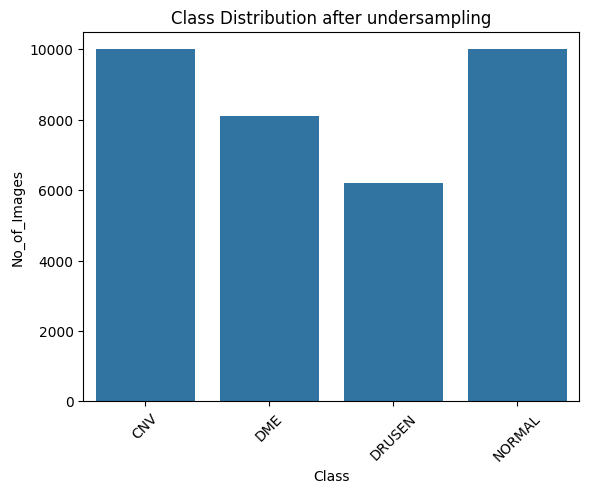

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.barplot(x=df["Class"],y= df["No_of_Images"])
plt.title("Class Distribution after undersampling")
plt.xticks(rotation= 45)
plt.show()

## Setting Parameters for Training on MobileNet V3 Model

In [23]:
training_set=image_dataset_from_directory(
    "C:/Users/HP/Downloads/ML/eye_disease/train",
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=16,
    image_size=(160, 160),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    
)

validation_set=image_dataset_from_directory(
    "C:/Users/HP/Downloads/ML/eye_disease/val",
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=16,
    image_size=(160, 160),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    
)


Found 34324 files belonging to 4 classes.
Found 21861 files belonging to 4 classes.


In [24]:
INPUT_SHAPE=[160,160,3]

In [25]:
mobnet=tf.keras.applications.MobileNetV3Large(
    input_shape=INPUT_SHAPE,
    alpha=1.0,
    minimalistic=False,
    include_top=False,
    weights="imagenet",
    input_tensor=None,
    classes=1000,
    pooling="avg",
    dropout_rate=0.2,
    classifier_activation="softmax",
    include_preprocessing=False,
    
)


### Adding Layers

In [26]:
#Initialize empty model
model = tf.keras.models.Sequential()

In [27]:
#input layer
model.add(tf.keras.layers.Input(shape=INPUT_SHAPE))

### Normalization


In [28]:
#Normalization
model.add(tf.keras.layers.Rescaling(scale=1./127.5, offset=-1))

In [29]:
# adding mobile net architecture
model.add(mobnet)

In [30]:
# output layers and Dense layers
model.add(tf.keras.layers.Dense(units=4,activation="softmax"))

### Adding Evaluation Metrics

In [31]:
import tensorflow_addons as tfa


number_of_classes= df["Class"].nunique()


metrics_list = [
    "accuracy",
    tfa.metrics.F1Score(num_classes=number_of_classes, average="macro"),
    tf.keras.metrics.Precision(name="precision"),
    tf.keras.metrics.Recall(name="recall")
]

c:\Users\HP\anaconda3\envs\ds_proj_env\lib\site-packages\tensorflow_addons\utils\tfa_eol_msg.py:23: UserWarning: 

TensorFlow Addons (TFA) has ended development and introduction of new features.
TFA has entered a minimal maintenance and release mode until a planned end of life in May 2024.
Please modify downstream libraries to take dependencies from other repositories in our TensorFlow community (e.g. Keras, Keras-CV, and Keras-NLP). 

For more information see: https://github.com/tensorflow/addons/issues/2807 

  warnings.warn(
c:\Users\HP\anaconda3\envs\ds_proj_env\lib\site-packages\tensorflow_addons\utils\ensure_tf_install.py:53: UserWarning: Tensorflow Addons supports using Python ops for all Tensorflow versions above or equal to 2.12.0 and strictly below 2.15.0 (nightly versions are not supported). 
 The versions of TensorFlow you are currently using is 2.10.0 and is not supported. 
Some things might work, some things might not.
If you were to encounter a bug, do not file an issue.

In [32]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
              loss=tf.keras.losses.CategoricalCrossentropy(),metrics=metrics_list)

In [33]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 rescaling (Rescaling)       (None, 160, 160, 3)       0         
                                                                 
 MobilenetV3large (Functiona  (None, 960)              2996352   
 l)                                                              
                                                                 
 dense (Dense)               (None, 4)                 3844      
                                                                 
Total params: 3,000,196
Trainable params: 2,975,796
Non-trainable params: 24,400
_________________________________________________________________


In [34]:
#if want to use transfer learning as then the mobile net
#layers weights will be freezed and train only on the dense layers

# mobnet.trainable=False

# GPU

### Check if gpu detected

In [35]:
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
print("GPUs available:", gpus)

if gpus:
    print(" GPU is detected")
else:
    print("No GPU detected")

GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
 GPU is detected


# Training


In [36]:
import time

t0 = time.time()
training_history=model.fit(training_set,validation_data=validation_set,epochs=30)
mobnet_train_time = time.time() - t0
print(f"MobileNetV3 training time: {mobnet_train_time:.1f}s")


Epoch 1/30
2146/2146 [==============================] - 265s 111ms/step - loss: 0.3661 - accuracy: 0.8661 - f1_score: 0.8557 - precision: 0.8875 - recall: 0.8462 - val_loss: 0.2157 - val_accuracy: 0.9274 - val_f1_score: 0.8831 - val_precision: 0.9319 - val_recall: 0.9232
Epoch 2/30
2146/2146 [==============================] - 207s 96ms/step - loss: 0.1761 - accuracy: 0.9401 - f1_score: 0.9355 - precision: 0.9436 - recall: 0.9364 - val_loss: 0.1842 - val_accuracy: 0.9409 - val_f1_score: 0.9053 - val_precision: 0.9432 - val_recall: 0.9385
Epoch 3/30
2146/2146 [==============================] - 205s 96ms/step - loss: 0.1100 - accuracy: 0.9612 - f1_score: 0.9582 - precision: 0.9632 - recall: 0.9594 - val_loss: 0.1671 - val_accuracy: 0.9489 - val_f1_score: 0.9162 - val_precision: 0.9509 - val_recall: 0.9475
Epoch 4/30
2146/2146 [==============================] - 206s 96ms/step - loss: 0.0706 - accuracy: 0.9758 - f1_score: 0.9739 - precision: 0.9770 - recall: 0.9748 - val_loss: 0.2047 - val_

### Seeing the Evaluation Metrics

Found 10932 files belonging to 4 classes.
684/684 [==============================] - 21s 30ms/step - loss: 0.3016 - accuracy: 0.9589 - f1_score: 0.9312 - precision: 0.9592 - recall: 0.9587
              precision    recall  f1-score   support

         CNV       0.99      0.94      0.96      3745
         DME       0.93      0.95      0.94      1161
      DRUSEN       0.79      0.89      0.84       887
      NORMAL       0.98      0.99      0.98      5139

    accuracy                           0.96     10932
   macro avg       0.92      0.94      0.93     10932
weighted avg       0.96      0.96      0.96     10932



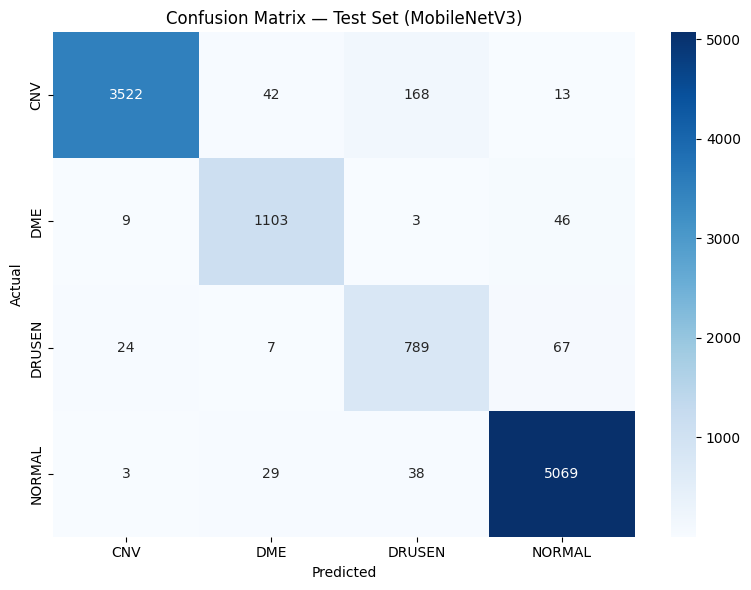

In [37]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

test_set = image_dataset_from_directory(
    "C:/Users/HP/Downloads/ML/eye_disease/test",
    labels="inferred",
    label_mode="categorical",
    color_mode="rgb",
    batch_size=16,
    image_size=(160, 160),
    shuffle=False,
)

test_loss, test_accuracy, test_f1_score, test_precision, test_recall = model.evaluate(test_set)
y_true, y_pred = [], []
for images, labels in test_set:
    preds = model.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

class_names = ["CNV", "DME", "DRUSEN", "NORMAL"]

print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — Test Set (MobileNetV3)")
plt.tight_layout()
plt.show()

# store for later comparison
mobnet_train_acc  = training_history.history['accuracy'][-1]
mobnet_val_acc    = training_history.history['val_accuracy'][-1]
mobnet_train_loss = training_history.history['loss'][-1]
mobnet_val_loss   = training_history.history['val_loss'][-1]
mobnet_test_acc   = test_accuracy
mobnet_test_prec  = test_precision
mobnet_test_rec   = test_recall
mobnet_history    = training_history.history


# Saving

In [38]:
model.save("trained_eye.keras")
training_history.history

{'loss': [0.36605167388916016,
  0.17612698674201965,
  0.11001913994550705,
  0.07064107060432434,
  0.048622217029333115,
  0.03884556144475937,
  0.03449029475450516,
  0.028921740129590034,
  0.026878662407398224,
  0.02485632710158825,
  0.023930953815579414,
  0.02147383615374565,
  0.01996879279613495,
  0.016949867829680443,
  0.017220772802829742,
  0.016673706471920013,
  0.015072118490934372,
  0.015563879162073135,
  0.01598338410258293,
  0.013100797310471535,
  0.015382210724055767,
  0.015146582387387753,
  0.014277446083724499,
  0.013974267058074474,
  0.01263074204325676,
  0.011934013105928898,
  0.012132029049098492,
  0.013944589532911777,
  0.013916859403252602,
  0.01172713004052639],
 'accuracy': [0.8660995364189148,
  0.9401293396949768,
  0.9612224698066711,
  0.9758186936378479,
  0.9840344786643982,
  0.9865691661834717,
  0.9885503053665161,
  0.9902109503746033,
  0.990706205368042,
  0.991521954536438,
  0.9914345741271973,
  0.9915511012077332,
  0.99286

In [43]:
#saving history
import pickle

with open("training_history.pkl", "wb") as f:
    pickle.dump(training_history.history,f)
    
    
print(f"MobileNetV3 training time: {mobnet_train_time:.1f}s")    
    

MobileNetV3 training time: 5860.6s


# using saved model

## reloading history from pickel file

In [40]:
model=tf.keras.models.load_model("trained_eye.keras")

In [41]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 rescaling (Rescaling)       (None, 160, 160, 3)       0         
                                                                 
 MobilenetV3large (Functiona  (None, 960)              2996352   
 l)                                                              
                                                                 
 dense (Dense)               (None, 4)                 3844      
                                                                 
Total params: 3,000,196
Trainable params: 2,975,796
Non-trainable params: 24,400
_________________________________________________________________


In [44]:
import pickle
with open("training_history.pkl", "rb") as f:
    load_history = pickle.load(f)

print(load_history)    

{'loss': [0.36605167388916016, 0.17612698674201965, 0.11001913994550705, 0.07064107060432434, 0.048622217029333115, 0.03884556144475937, 0.03449029475450516, 0.028921740129590034, 0.026878662407398224, 0.02485632710158825, 0.023930953815579414, 0.02147383615374565, 0.01996879279613495, 0.016949867829680443, 0.017220772802829742, 0.016673706471920013, 0.015072118490934372, 0.015563879162073135, 0.01598338410258293, 0.013100797310471535, 0.015382210724055767, 0.015146582387387753, 0.014277446083724499, 0.013974267058074474, 0.01263074204325676, 0.011934013105928898, 0.012132029049098492, 0.013944589532911777, 0.013916859403252602, 0.01172713004052639], 'accuracy': [0.8660995364189148, 0.9401293396949768, 0.9612224698066711, 0.9758186936378479, 0.9840344786643982, 0.9865691661834717, 0.9885503053665161, 0.9902109503746033, 0.990706205368042, 0.991521954536438, 0.9914345741271973, 0.9915511012077332, 0.9928621649742126, 0.9929495453834534, 0.9933574199676514, 0.9936779141426086, 0.99382358

In [45]:
load_history.keys()

dict_keys(['loss', 'accuracy', 'f1_score', 'precision', 'recall', 'val_loss', 'val_accuracy', 'val_f1_score', 'val_precision', 'val_recall'])

### loss visualisation

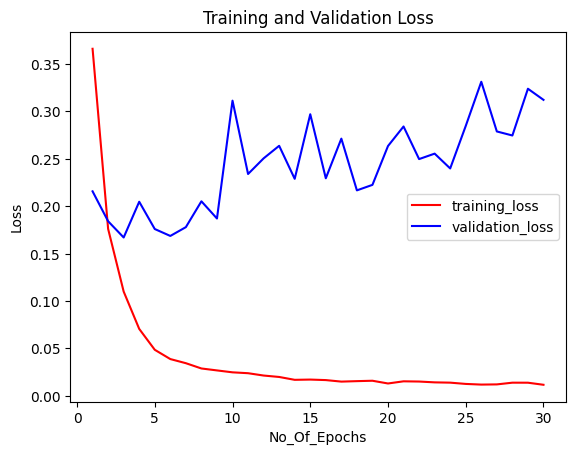

In [46]:
epochs=[i for i in range(1,31)]
plt.plot(epochs,load_history['loss'],color='red' ,label="training_loss")
plt.plot(epochs,load_history['val_loss'],color='blue' ,label="validation_loss")
plt.xlabel("No_Of_Epochs") 
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()


# Custom CNN

## Setting Parameters for Training on Custom CNN

In [47]:
cnn_train_set = image_dataset_from_directory(
    "C:/Users/HP/Downloads/ML/eye_disease/train",
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
)

cnn_val_set = image_dataset_from_directory(
    "C:/Users/HP/Downloads/ML/eye_disease/val",
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
)


Found 34324 files belonging to 4 classes.
Found 21861 files belonging to 4 classes.


In [48]:
CNN_INPUT_SHAPE = [128, 128, 3]


### Building the CNN

In [49]:
from tensorflow.keras import layers

cnn_model = tf.keras.models.Sequential([
    layers.Input(shape=CNN_INPUT_SHAPE),
    layers.Rescaling(1./255),

    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(4, activation='softmax')
])


### Adding Evaluation Metrics

In [50]:
cnn_metrics_list = [
    "accuracy",
    tfa.metrics.F1Score(num_classes=number_of_classes, average="macro"),
    tf.keras.metrics.Precision(name="precision"),
    tf.keras.metrics.Recall(name="recall")
]

cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.CategoricalCrossentropy(),
    metrics=cnn_metrics_list
)

cnn_model.summary()


Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 rescaling_1 (Rescaling)     (None, 128, 128, 3)       0         
                                                                 
 conv2d (Conv2D)             (None, 128, 128, 32)      896       
                                                                 
 batch_normalization (BatchN  (None, 128, 128, 32)     128       
 ormalization)                                                   
                                                                 
 max_pooling2d (MaxPooling2D  (None, 64, 64, 32)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 64, 64, 64)        18496     
                                                                 
 batch_normalization_1 (Batc  (None, 64, 64, 64)      

# Training CNN

In [51]:
import time

t0 = time.time()
cnn_history = cnn_model.fit(cnn_train_set, validation_data=cnn_val_set, epochs=30)
cnn_train_time = time.time() - t0
print(f"CNN training time: {cnn_train_time:.1f}s")


Epoch 1/30
1073/1073 [==============================] - 136s 123ms/step - loss: 1.2293 - accuracy: 0.4880 - f1_score: 0.3938 - precision: 0.6876 - recall: 0.3010 - val_loss: 0.6583 - val_accuracy: 0.7661 - val_f1_score: 0.5846 - val_precision: 0.8790 - val_recall: 0.6549
Epoch 2/30
1073/1073 [==============================] - 105s 97ms/step - loss: 0.6160 - accuracy: 0.7613 - f1_score: 0.7334 - precision: 0.8264 - recall: 0.6907 - val_loss: 0.4960 - val_accuracy: 0.8484 - val_f1_score: 0.7195 - val_precision: 0.8626 - val_recall: 0.8353
Epoch 3/30
1073/1073 [==============================] - 126s 117ms/step - loss: 0.4305 - accuracy: 0.8479 - f1_score: 0.8355 - precision: 0.8796 - recall: 0.8121 - val_loss: 0.3860 - val_accuracy: 0.8999 - val_f1_score: 0.8024 - val_precision: 0.9075 - val_recall: 0.8948
Epoch 4/30
1073/1073 [==============================] - 145s 135ms/step - loss: 0.3541 - accuracy: 0.8803 - f1_score: 0.8710 - precision: 0.9013 - recall: 0.8538 - val_loss: 0.2881 - va

### Evaluation Metrics

Found 10932 files belonging to 4 classes.
342/342 [==============================] - 17s 50ms/step - loss: 0.4220 - accuracy: 0.9442 - f1_score: 0.9051 - precision: 0.9458 - recall: 0.9429
              precision    recall  f1-score   support

         CNV       0.97      0.93      0.95      3745
         DME       0.86      0.95      0.90      1161
      DRUSEN       0.84      0.75      0.79       887
      NORMAL       0.96      0.99      0.97      5139

    accuracy                           0.94     10932
   macro avg       0.91      0.91      0.91     10932
weighted avg       0.94      0.94      0.94     10932



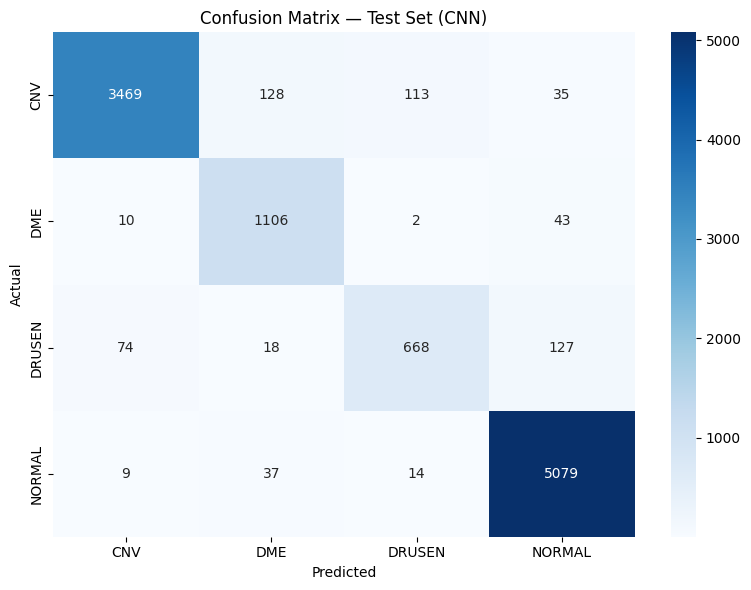

In [52]:
cnn_test_set = image_dataset_from_directory(
    "C:/Users/HP/Downloads/ML/eye_disease/test",
    labels="inferred",
    label_mode="categorical",
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=False,
)

cnn_test_loss, cnn_test_accuracy, cnn_test_f1, cnn_test_precision, cnn_test_recall = cnn_model.evaluate(cnn_test_set)

y_true_cnn, y_pred_cnn = [], []
for images, labels in cnn_test_set:
    preds = cnn_model.predict(images, verbose=0)
    y_true_cnn.extend(np.argmax(labels.numpy(), axis=1))
    y_pred_cnn.extend(np.argmax(preds, axis=1))

print(classification_report(y_true_cnn, y_pred_cnn, target_names=class_names))

cm_cnn = confusion_matrix(y_true_cnn, y_pred_cnn)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_cnn, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — Test Set (CNN)")
plt.tight_layout()
plt.show()

cnn_train_acc  = cnn_history.history['accuracy'][-1]
cnn_val_acc    = cnn_history.history['val_accuracy'][-1]
cnn_train_loss = cnn_history.history['loss'][-1]
cnn_val_loss   = cnn_history.history['val_loss'][-1]


# Saving CNN

In [53]:
cnn_model.save("trained_eye_cnn.keras")

import pickle
with open("training_history_cnn.pkl", "wb") as f:
    pickle.dump(cnn_history.history, f)


### loss visualisation

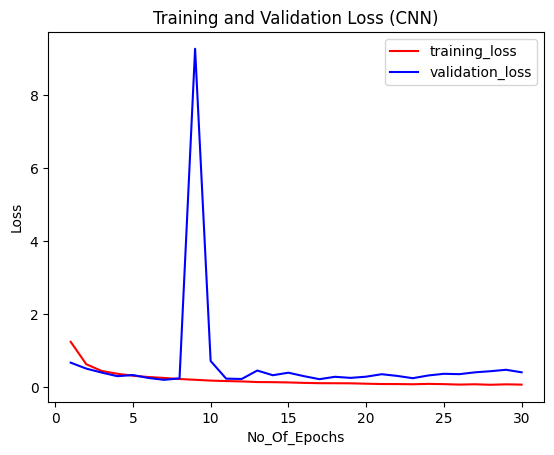

In [54]:
epochs=[i for i in range(1,31)]
plt.plot(epochs,cnn_history.history['loss'],color='red' ,label="training_loss")
plt.plot(epochs,cnn_history.history['val_loss'],color='blue' ,label="validation_loss")
plt.xlabel("No_Of_Epochs") 
plt.ylabel("Loss")
plt.title("Training and Validation Loss (CNN)")
plt.legend()
plt.show()


# ResNet50

## Setting Parameters for Training on ResNet50 Model

In [55]:
RN_INPUT_SHAPE = [160, 160, 3]

rn_train_set = image_dataset_from_directory(
    "C:/Users/HP/Downloads/ML/eye_disease/train",
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=16,
    image_size=(160, 160),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
)

rn_val_set = image_dataset_from_directory(
    "C:/Users/HP/Downloads/ML/eye_disease/val",
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=16,
    image_size=(160, 160),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
)


Found 34324 files belonging to 4 classes.
Found 21861 files belonging to 4 classes.


In [56]:
resnet = tf.keras.applications.ResNet50(
    input_shape=RN_INPUT_SHAPE,
    include_top=False,
    weights="imagenet",
    pooling="avg",
)


94765736/94765736 [==============================] - 12s 0us/step


### Adding Layers

In [57]:
#Initialize empty model
rn_model = tf.keras.models.Sequential()


In [58]:
#input layer
rn_model.add(tf.keras.layers.Input(shape=RN_INPUT_SHAPE))


### Normalization

In [59]:
#Normalization
rn_model.add(tf.keras.layers.Rescaling(scale=1./127.5, offset=-1))


In [60]:
# adding resnet50 architecture
rn_model.add(resnet)


In [61]:
# output layers and Dense layers
rn_model.add(tf.keras.layers.Dense(units=4,activation="softmax"))


### Adding Evaluation Metrics

In [62]:
rn_metrics_list = [
    "accuracy",
    tfa.metrics.F1Score(num_classes=number_of_classes, average="macro"),
    tf.keras.metrics.Precision(name="precision"),
    tf.keras.metrics.Recall(name="recall")
]

rn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss=tf.keras.losses.CategoricalCrossentropy(),
    metrics=rn_metrics_list
)

rn_model.summary()


Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 rescaling_2 (Rescaling)     (None, 160, 160, 3)       0         
                                                                 
 resnet50 (Functional)       (None, 2048)              23587712  
                                                                 
 dense_3 (Dense)             (None, 4)                 8196      
                                                                 
Total params: 23,595,908
Trainable params: 23,542,788
Non-trainable params: 53,120
_________________________________________________________________


# Training ResNet50

In [63]:
t0 = time.time()
rn_history = rn_model.fit(rn_train_set, validation_data=rn_val_set, epochs=30)
rn_train_time = time.time() - t0
print(f"ResNet50 training time: {rn_train_time:.1f}s")


Epoch 1/30
2146/2146 [==============================] - 499s 228ms/step - loss: 0.2959 - accuracy: 0.9000 - f1_score: 0.8929 - precision: 0.9110 - recall: 0.8895 - val_loss: 0.1288 - val_accuracy: 0.9590 - val_f1_score: 0.9300 - val_precision: 0.9608 - val_recall: 0.9571
Epoch 2/30
2146/2146 [==============================] - 486s 226ms/step - loss: 0.1581 - accuracy: 0.9478 - f1_score: 0.9442 - precision: 0.9512 - recall: 0.9451 - val_loss: 0.1504 - val_accuracy: 0.9525 - val_f1_score: 0.9213 - val_precision: 0.9554 - val_recall: 0.9500
Epoch 3/30
2146/2146 [==============================] - 491s 229ms/step - loss: 0.1014 - accuracy: 0.9662 - f1_score: 0.9639 - precision: 0.9675 - recall: 0.9650 - val_loss: 0.1310 - val_accuracy: 0.9597 - val_f1_score: 0.9325 - val_precision: 0.9611 - val_recall: 0.9588
Epoch 4/30
2146/2146 [==============================] - 492s 229ms/step - loss: 0.0731 - accuracy: 0.9753 - f1_score: 0.9735 - precision: 0.9762 - recall: 0.9744 - val_loss: 0.1347 - v

### Seeing the Evaluation Metrics

Found 10932 files belonging to 4 classes.
684/684 [==============================] - 37s 54ms/step - loss: 2.0307 - accuracy: 0.6534 - f1_score: 0.6133 - precision: 0.6537 - recall: 0.6529
              precision    recall  f1-score   support

         CNV       0.99      0.73      0.84      3745
         DME       0.24      0.99      0.38      1161
      DRUSEN       0.92      0.34      0.50       887
      NORMAL       0.99      0.57      0.73      5139

    accuracy                           0.65     10932
   macro avg       0.79      0.66      0.61     10932
weighted avg       0.91      0.65      0.71     10932



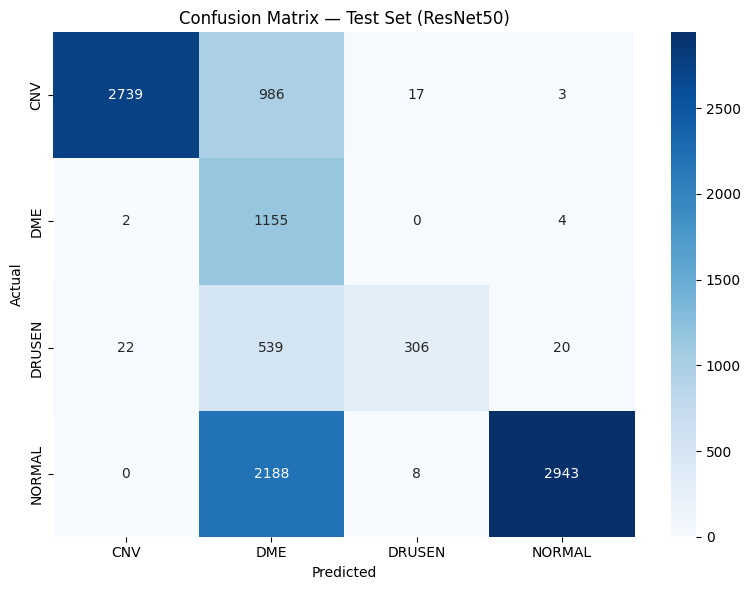

In [64]:
rn_test_set = image_dataset_from_directory(
    "C:/Users/HP/Downloads/ML/eye_disease/test",
    labels="inferred",
    label_mode="categorical",
    color_mode="rgb",
    batch_size=16,
    image_size=(160, 160),
    shuffle=False,
)

rn_test_loss, rn_test_accuracy, rn_test_f1, rn_test_precision, rn_test_recall = rn_model.evaluate(rn_test_set)

y_true_rn, y_pred_rn = [], []
for images, labels in rn_test_set:
    preds = rn_model.predict(images, verbose=0)
    y_true_rn.extend(np.argmax(labels.numpy(), axis=1))
    y_pred_rn.extend(np.argmax(preds, axis=1))

print(classification_report(y_true_rn, y_pred_rn, target_names=class_names))

cm_rn = confusion_matrix(y_true_rn, y_pred_rn)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rn, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — Test Set (ResNet50)")
plt.tight_layout()
plt.show()

rn_train_acc  = rn_history.history['accuracy'][-1]
rn_val_acc    = rn_history.history['val_accuracy'][-1]
rn_train_loss = rn_history.history['loss'][-1]
rn_val_loss   = rn_history.history['val_loss'][-1]


# Saving ResNet50

In [65]:
rn_model.save("trained_eye_resnet50.keras")

import pickle
with open("training_history_resnet50.pkl", "wb") as f:
    pickle.dump(rn_history.history, f)


### loss visualisation

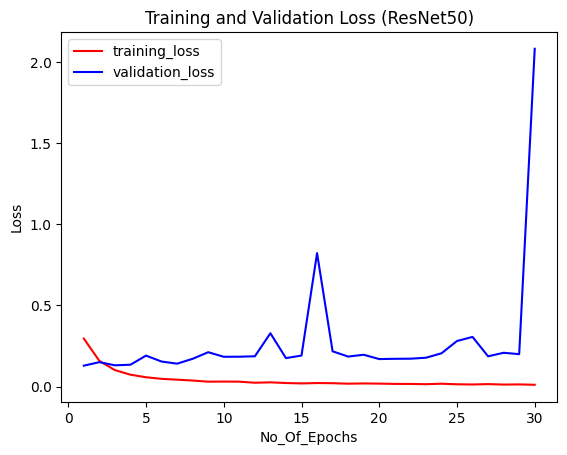

In [66]:
epochs=[i for i in range(1,31)]
plt.plot(epochs,rn_history.history['loss'],color='red' ,label="training_loss")
plt.plot(epochs,rn_history.history['val_loss'],color='blue' ,label="validation_loss")
plt.xlabel("No_Of_Epochs") 
plt.ylabel("Loss")
plt.title("Training and Validation Loss (ResNet50)")
plt.legend()
plt.show()


# EfficientNetB0

## Setting Parameters for Training on EfficientNetB0 Model

In [67]:
EN_INPUT_SHAPE = [160, 160, 3]

en_train_set = image_dataset_from_directory(
    "C:/Users/HP/Downloads/ML/eye_disease/train",
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=16,
    image_size=(160, 160),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
)

en_val_set = image_dataset_from_directory(
    "C:/Users/HP/Downloads/ML/eye_disease/val",
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=16,
    image_size=(160, 160),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
)


Found 34324 files belonging to 4 classes.
Found 21861 files belonging to 4 classes.


In [68]:
effnet = tf.keras.applications.EfficientNetB0(
    input_shape=EN_INPUT_SHAPE,
    include_top=False,
    weights="imagenet",
    pooling="avg",
)


16705208/16705208 [==============================] - 5s 0us/step


### Adding Layers

In [69]:
#Initialize empty model
en_model = tf.keras.models.Sequential()


In [70]:
#input layer
en_model.add(tf.keras.layers.Input(shape=EN_INPUT_SHAPE))


### Normalization

In [71]:
#Normalization
en_model.add(tf.keras.layers.Rescaling(scale=1./127.5, offset=-1))


In [72]:
# adding efficientnetb0 architecture
en_model.add(effnet)


In [73]:
# output layers and Dense layers
en_model.add(tf.keras.layers.Dense(units=4,activation="softmax"))


### Adding Evaluation Metrics

In [74]:
en_metrics_list = [
    "accuracy",
    tfa.metrics.F1Score(num_classes=number_of_classes, average="macro"),
    tf.keras.metrics.Precision(name="precision"),
    tf.keras.metrics.Recall(name="recall")
]

en_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss=tf.keras.losses.CategoricalCrossentropy(),
    metrics=en_metrics_list
)

en_model.summary()


Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 rescaling_5 (Rescaling)     (None, 160, 160, 3)       0         
                                                                 
 efficientnetb0 (Functional)  (None, 1280)             4049571   
                                                                 
 dense_4 (Dense)             (None, 4)                 5124      
                                                                 
Total params: 4,054,695
Trainable params: 4,012,672
Non-trainable params: 42,023
_________________________________________________________________


# Training EfficientNetB0

In [75]:
t0 = time.time()
en_history = en_model.fit(en_train_set, validation_data=en_val_set, epochs=30)
en_train_time = time.time() - t0
print(f"EfficientNetB0 training time: {en_train_time:.1f}s")


Epoch 1/30
2146/2146 [==============================] - 361s 162ms/step - loss: 0.3633 - accuracy: 0.8685 - f1_score: 0.8585 - precision: 0.8944 - recall: 0.8443 - val_loss: 0.9219 - val_accuracy: 0.7930 - val_f1_score: 0.6060 - val_precision: 0.9491 - val_recall: 0.2425
Epoch 2/30
2146/2146 [==============================] - 417s 194ms/step - loss: 0.1872 - accuracy: 0.9359 - f1_score: 0.9311 - precision: 0.9395 - recall: 0.9322 - val_loss: 0.8747 - val_accuracy: 0.7636 - val_f1_score: 0.5240 - val_precision: 0.9033 - val_recall: 0.3811
Epoch 3/30
2146/2146 [==============================] - 501s 233ms/step - loss: 0.1307 - accuracy: 0.9550 - f1_score: 0.9515 - precision: 0.9571 - recall: 0.9531 - val_loss: 0.5744 - val_accuracy: 0.7942 - val_f1_score: 0.6803 - val_precision: 0.8409 - val_recall: 0.7193
Epoch 4/30
2146/2146 [==============================] - 352s 164ms/step - loss: 0.0961 - accuracy: 0.9670 - f1_score: 0.9644 - precision: 0.9680 - recall: 0.9654 - val_loss: 1.1088 - v

### Seeing the Evaluation Metrics

Found 10932 files belonging to 4 classes.
684/684 [==============================] - 27s 39ms/step - loss: 0.3323 - accuracy: 0.9392 - f1_score: 0.9007 - precision: 0.9401 - recall: 0.9387
              precision    recall  f1-score   support

         CNV       0.99      0.92      0.95      3745
         DME       0.91      0.85      0.88      1161
      DRUSEN       0.74      0.89      0.80       887
      NORMAL       0.95      0.98      0.97      5139

    accuracy                           0.94     10932
   macro avg       0.90      0.91      0.90     10932
weighted avg       0.94      0.94      0.94     10932



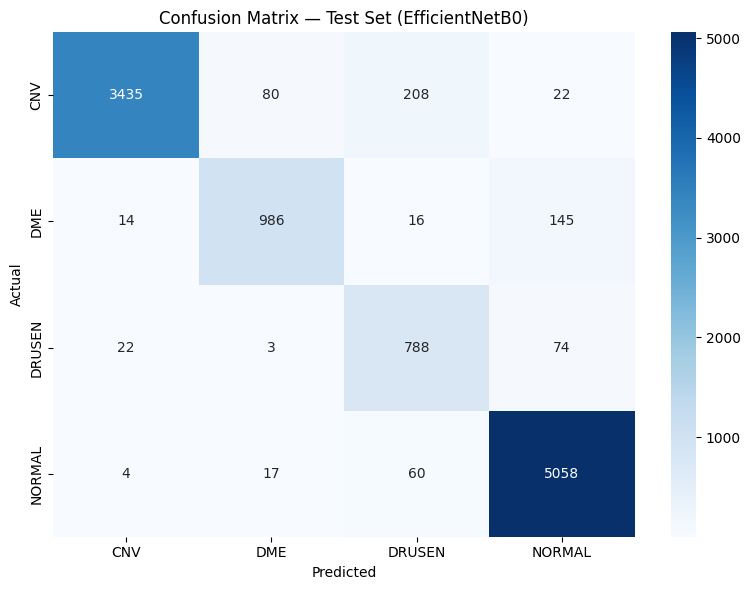

In [76]:
en_test_set = image_dataset_from_directory(
    "C:/Users/HP/Downloads/ML/eye_disease/test",
    labels="inferred",
    label_mode="categorical",
    color_mode="rgb",
    batch_size=16,
    image_size=(160, 160),
    shuffle=False,
)

en_test_loss, en_test_accuracy, en_test_f1, en_test_precision, en_test_recall = en_model.evaluate(en_test_set)

y_true_en, y_pred_en = [], []
for images, labels in en_test_set:
    preds = en_model.predict(images, verbose=0)
    y_true_en.extend(np.argmax(labels.numpy(), axis=1))
    y_pred_en.extend(np.argmax(preds, axis=1))

print(classification_report(y_true_en, y_pred_en, target_names=class_names))

cm_en = confusion_matrix(y_true_en, y_pred_en)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_en, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — Test Set (EfficientNetB0)")
plt.tight_layout()
plt.show()

en_train_acc  = en_history.history['accuracy'][-1]
en_val_acc    = en_history.history['val_accuracy'][-1]
en_train_loss = en_history.history['loss'][-1]
en_val_loss   = en_history.history['val_loss'][-1]


# Saving EfficientNetB0

In [79]:
en_model.save_weights("trained_eye_efficientnet_weights.h5")

import pickle
with open("training_history_efficientnet.pkl", "wb") as f:
    pickle.dump(en_history.history, f)


### loss visualisation

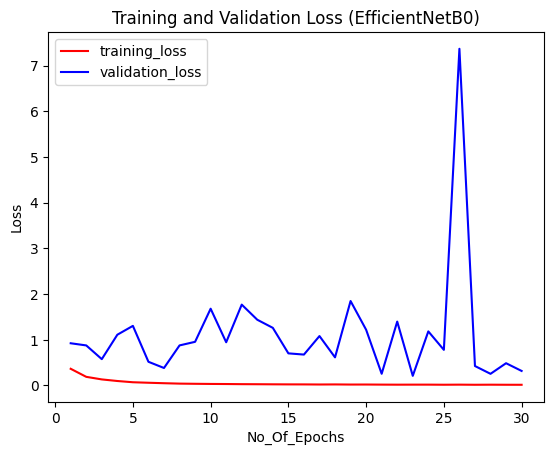

In [80]:
epochs=[i for i in range(1,31)]
plt.plot(epochs,en_history.history['loss'],color='red' ,label="training_loss")
plt.plot(epochs,en_history.history['val_loss'],color='blue' ,label="validation_loss")
plt.xlabel("No_Of_Epochs") 
plt.ylabel("Loss")
plt.title("Training and Validation Loss (EfficientNetB0)")
plt.legend()
plt.show()


# Model Comparison

## Summary Table — Accuracy, Precision, Recall and Training Time

In [81]:
import pandas as pd

comparison_df = pd.DataFrame({
    "Model": ["MobileNetV3", "CNN", "ResNet50", "EfficientNetB0"],
    "Train Acc": [
        round(mobnet_train_acc, 4),
        round(cnn_train_acc, 4),
        round(rn_train_acc, 4),
        round(en_train_acc, 4),
    ],
    "Val Acc": [
        round(mobnet_val_acc, 4),
        round(cnn_val_acc, 4),
        round(rn_val_acc, 4),
        round(en_val_acc, 4),
    ],
    "Test Acc": [
        round(mobnet_test_acc, 4),
        round(cnn_test_accuracy, 4),
        round(rn_test_accuracy, 4),
        round(en_test_accuracy, 4),
    ],
    "Test Precision": [
        round(mobnet_test_prec, 4),
        round(cnn_test_precision, 4),
        round(rn_test_precision, 4),
        round(en_test_precision, 4),
    ],
    "Test Recall": [
        round(mobnet_test_rec, 4),
        round(cnn_test_recall, 4),
        round(rn_test_recall, 4),
        round(en_test_recall, 4),
    ],
    "Train Time (s)": [
        round(mobnet_train_time, 1),
        round(cnn_train_time, 1),
        round(rn_train_time, 1),
        round(en_train_time, 1),
    ],
})

print(comparison_df.to_string(index=False))


         Model  Train Acc  Val Acc  Test Acc  Test Precision  Test Recall  Train Time (s)
   MobileNetV3     0.9953   0.9566    0.9589          0.9592       0.9587          5860.6
           CNN     0.9826   0.9456    0.9442          0.9458       0.9429          4150.1
      ResNet50     0.9956   0.6483    0.6534          0.6537       0.6529         14936.2
EfficientNetB0     0.9950   0.9430    0.9392          0.9401       0.9387         10543.4


## Comparison Graphs

C:\Users\HP\AppData\Local\Temp\ipykernel_19876\3514806906.py:32: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(model_names, rotation=15)
C:\Users\HP\AppData\Local\Temp\ipykernel_19876\3514806906.py:40: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(model_names, rotation=15)
C:\Users\HP\AppData\Local\Temp\ipykernel_19876\3514806906.py:48: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(model_names, rotation=15)


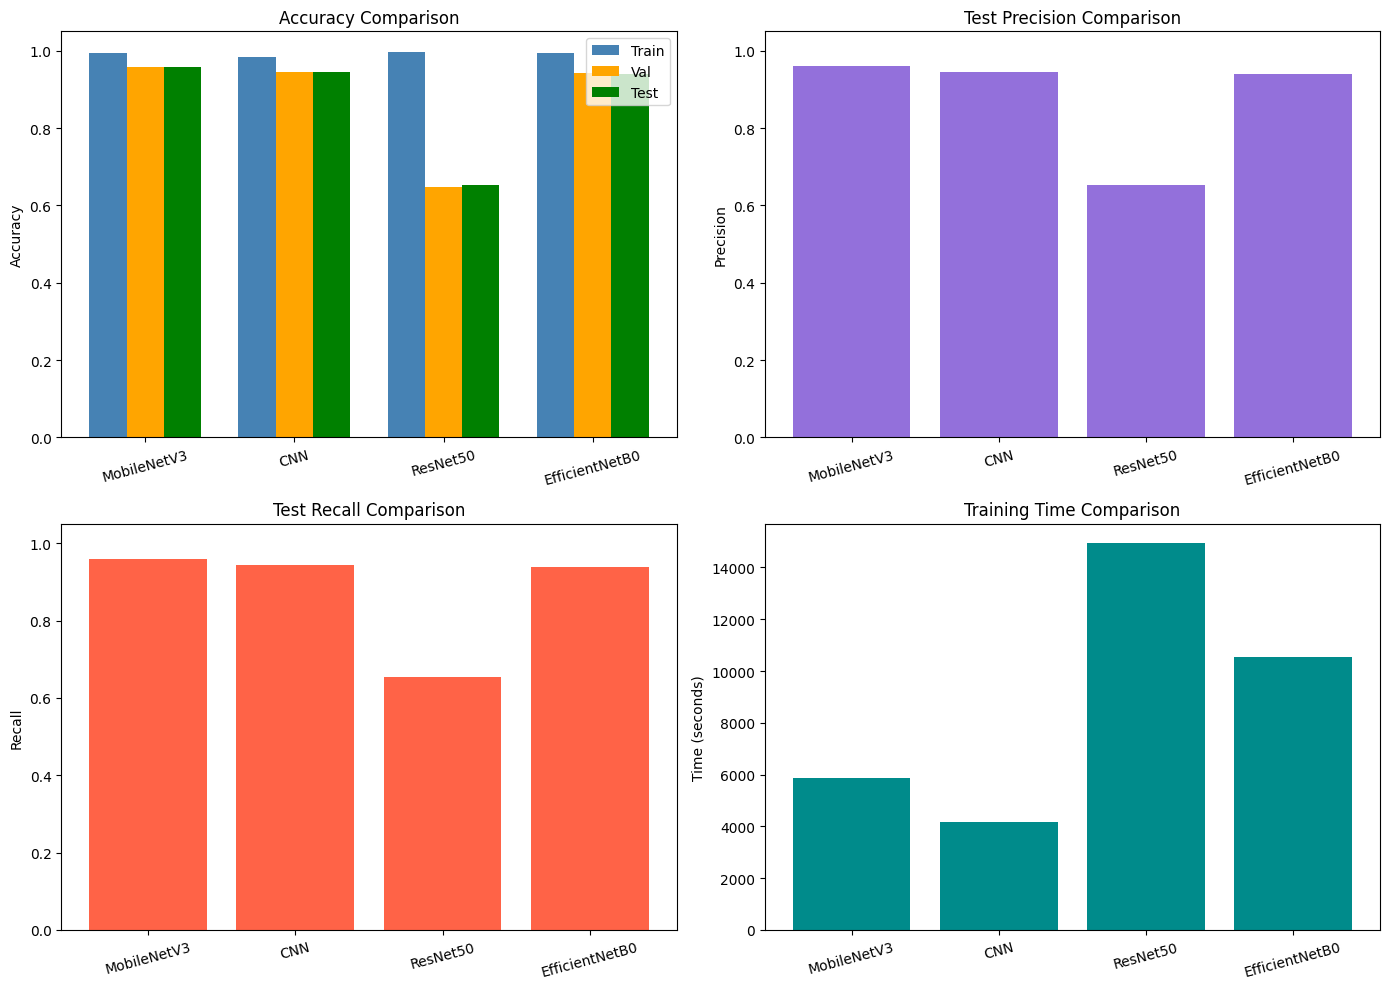

In [82]:
model_names = ["MobileNetV3", "CNN", "ResNet50", "EfficientNetB0"]

train_accs = [mobnet_train_acc, cnn_train_acc, rn_train_acc, en_train_acc]
val_accs   = [mobnet_val_acc,   cnn_val_acc,   rn_val_acc,   en_val_acc]
test_accs  = [mobnet_test_acc,  cnn_test_accuracy, rn_test_accuracy, en_test_accuracy]
test_precs = [mobnet_test_prec, cnn_test_precision, rn_test_precision, en_test_precision]
test_recs  = [mobnet_test_rec,  cnn_test_recall, rn_test_recall, en_test_recall]
train_times= [mobnet_train_time, cnn_train_time, rn_train_time, en_train_time]

x = range(len(model_names))
width = 0.25

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Accuracy comparison
ax = axes[0, 0]
ax.bar([i - width for i in x], train_accs, width, label='Train', color='steelblue')
ax.bar([i         for i in x], val_accs,   width, label='Val',   color='orange')
ax.bar([i + width for i in x], test_accs,  width, label='Test',  color='green')
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=15)
ax.set_ylabel('Accuracy')
ax.set_title('Accuracy Comparison')
ax.legend()
ax.set_ylim(0, 1.05)

# Precision comparison
ax = axes[0, 1]
ax.bar(model_names, test_precs, color='mediumpurple')
ax.set_ylabel('Precision')
ax.set_title('Test Precision Comparison')
ax.set_xticklabels(model_names, rotation=15)
ax.set_ylim(0, 1.05)

# Recall comparison
ax = axes[1, 0]
ax.bar(model_names, test_recs, color='tomato')
ax.set_ylabel('Recall')
ax.set_title('Test Recall Comparison')
ax.set_xticklabels(model_names, rotation=15)
ax.set_ylim(0, 1.05)

# Training time comparison
ax = axes[1, 1]
ax.bar(model_names, train_times, color='darkcyan')
ax.set_ylabel('Time (seconds)')
ax.set_title('Training Time Comparison')
ax.set_xticklabels(model_names, rotation=15)

plt.tight_layout()
plt.show()


### Training & Validation Loss — All Models

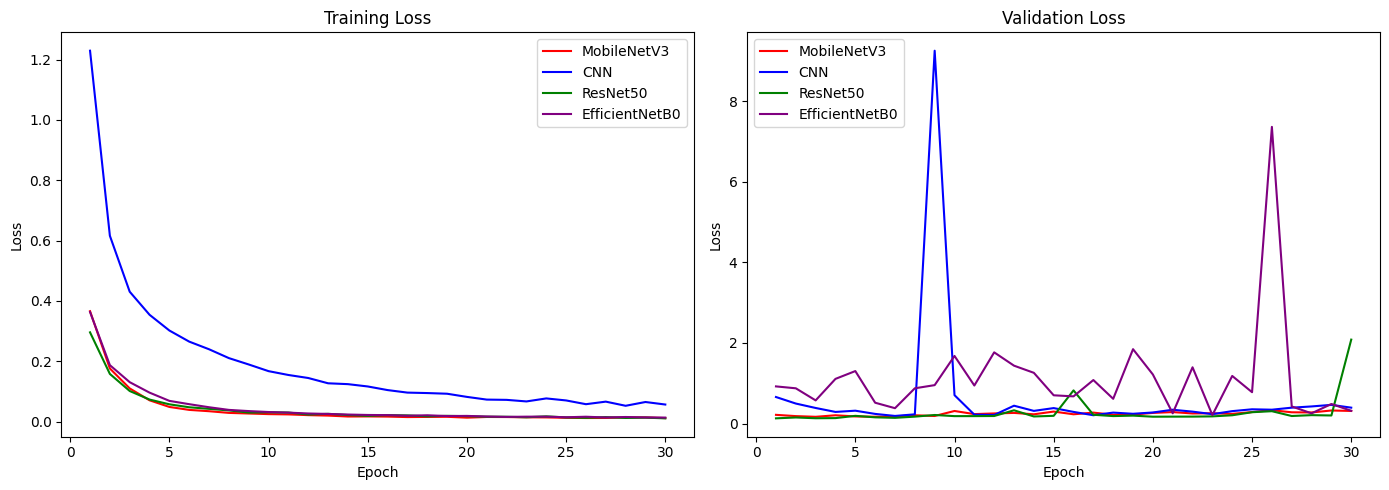

In [83]:
all_histories = {
    "MobileNetV3":   mobnet_history,
    "CNN":           cnn_history.history,
    "ResNet50":      rn_history.history,
    "EfficientNetB0": en_history.history,
}

colors = ['red', 'blue', 'green', 'purple']
epochs = [i for i in range(1, 31)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for (name, hist), color in zip(all_histories.items(), colors):
    axes[0].plot(epochs, hist['loss'], color=color, label=name)
    axes[1].plot(epochs, hist['val_loss'], color=color, label=name)

axes[0].set_title('Training Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].set_title('Validation Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()


### Training & Validation Accuracy — All Models

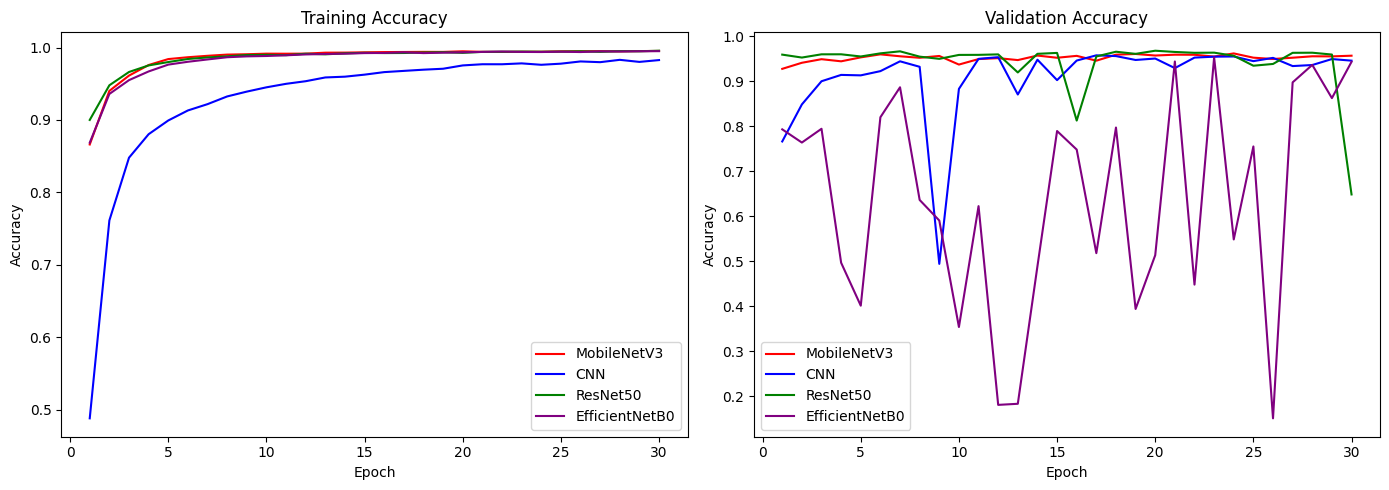

In [84]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for (name, hist), color in zip(all_histories.items(), colors):
    axes[0].plot(epochs, hist['accuracy'], color=color, label=name)
    axes[1].plot(epochs, hist['val_accuracy'], color=color, label=name)

axes[0].set_title('Training Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].set_title('Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()
